# 04 — Aprendizado por Reforço: Bandit de Recomendação

## Bloco 1 — Contexto e pergunta

Nos dois notebooks anteriores, a tarefa era bem definida pelo dataset:

- No supervisionado, o rótulo `gostou` já estava disponível — o modelo aprendia a prever.
- No não supervisionado, a estrutura existia nos dados — o algoritmo a revelava.

Agora a pergunta é operacional e nenhuma dessas condições se aplica:

**Qual filme recomendar agora?**

Não há rótulo dizendo qual recomendação é correta. Não há estrutura a descobrir. Há uma **decisão** — escolher qual filme mostrar — e uma **consequência** — o usuário reage e gera um sinal de feedback.

| Aspecto | Supervisionado | Não supervisionado | Aprendizado por Reforço |
|---|---|---|---|
| O que existe no dado? | Rótulo `y` | Apenas features `x` | Histórico de interações |
| O que o sistema faz? | Prevê `y` | Descobre estrutura | Age e observa consequência |
| O sinal de aprendizado | Erro de previsão | Similaridade interna | Recompensa após a ação |

O RL é o paradigma adequado quando o objetivo é aprender uma **estratégia de decisão** — e não apenas uma previsão ou uma segmentação.

## Informações do notebook

| Item | Detalhe |
|---|---|
| **Aula** | Aula 01 — Paradigmas de ML com MovieLens |
| **Notebook** | 04 — RL: Bandit de Recomendação |
| **Seções** | 1.4 — Aprendizado por Reforço e formulação MDP |
| **Tempo de leitura** | 20 min |
| **Tempo de execução (padrão)** | 5 min |
| **Exercícios** | 4 questões de autoavaliação |

### Pré-requisitos

- **Notebooks anteriores:** `02_supervisionado_preferencia.ipynb` e `03_nao_supervisionado_perfis.ipynb`.
- **Conceitos:** rótulo, cluster, probabilidade, laço de otimização.

### Competências para o Desafio Final

- Formular o problema de recomendação como MDP: definir estados, ações, recompensa e fator de desconto.
- Implementar uma política ε-greedy e compreender o dilema exploração vs. explotação.
- Calcular e interpretar recompensa acumulada e *regret* em um episódio de recomendação.

### Recapitulando

No notebook anterior descobrimos **perfis latentes de usuários** via K-Means (3 clusters por padrão de consumo por gênero). Os clusters revelam que usuários têm gostos distintos — mas não determinam *qual filme mostrar agora*. A limitação central: a segmentação opera em lote sobre dados históricos e não aprende com o feedback individual de cada interação.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0


torch                2.11.0+cpu
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1


scikit-learn         1.8.0


## Bloco 2 — Mini teoria

### Conceitos fundamentais de RL

O Aprendizado por Reforço define um ciclo de interação entre dois elementos:

- **Agente:** o sistema que toma decisões — aqui, o mecanismo de recomendação da plataforma.
- **Ambiente:** tudo que está além do agente e que responde às suas ações — o usuário e seu comportamento.

O ciclo funciona assim:
1. O agente observa o **estado** atual do ambiente.
2. O agente seleciona uma **ação**.
3. O ambiente devolve uma **recompensa** e o novo estado.
4. O agente atualiza sua **política** com base nessa experiência.

Esse ciclo se repete ao longo de um **episódio** — uma sequência de interações com início e fim definidos. O objetivo não é maximizar a recompensa de uma única rodada, mas o **retorno cumulativo**: a soma ponderada das recompensas ao longo de todo o episódio.

**Exploração vs. aproveitamento**
O agente enfrenta um dilema permanente:
- *Exploração:* tentar ações pouco conhecidas para descobrir recompensas melhores ainda não mapeadas.
- *Aproveitamento:* usar o conhecimento já acumulado e escolher a ação com maior valor estimado.

Explorar demais desperdiça recompensa imediata. Aproveitar demais impede a descoberta de ações superiores. O equilíbrio entre os dois determina a qualidade do aprendizado.

---

### Formulação formal: o Processo de Decisão de Markov (MDP)

O RL é formalizado como um **MDP**, definido por cinco componentes. Cada um tem uma interpretação concreta no contexto do sistema de recomendação MovieLens:

| Componente | Símbolo | Definição | No contexto MovieLens |
|---|---|---|---|
| Estados | S | O que o agente observa do ambiente | Perfil resumido do usuário: gêneros preferidos, histórico recente, quantidade de avaliações |
| Ações | A | O conjunto de decisões disponíveis | Escolher qual filme recomendar entre os candidatos |
| Transições | T | Como o estado muda após a ação | A interação com o filme atualiza o histórico e o perfil do usuário, alterando o estado seguinte |
| Recompensas | R | Sinal de feedback após cada ação | Nota ≥ 4 gera recompensa 1; nota < 4 ou ausência de engajamento gera 0 |
| Desconto | γ | Peso das recompensas futuras vs. imediatas | γ próximo de 1: o agente considera o longo prazo; γ próximo de 0: o agente é míope |

O MDP não é apenas um formalismo — é o vocabulário preciso que descreve qualquer problema de decisão sequencial. É com esse vocabulário que as próximas aulas tratarão algoritmos como Q-Learning, SARSA e PPO.

---

### Política determinística e estocástica

A **política** (π) é a regra que mapeia estados a ações.

- **Política determinística:** dado um estado, o agente sempre escolhe a mesma ação. *No contexto MovieLens:* para um usuário com perfil de fã de ação, sempre recomendar o filme de ação com maior probabilidade histórica de satisfação.
- **Política estocástica:** dado um estado, o agente escolhe ações com diferentes probabilidades. *No contexto MovieLens:* recomendar o filme de ação com 70% de probabilidade e explorar outras opções com 30%. Esse tipo de política é especialmente útil durante o aprendizado, pois mantém exploração ativa.

A política **epsilon-greedy** implementada neste notebook é estocástica: com probabilidade ε o agente escolhe aleatoriamente (exploração) e com probabilidade 1−ε escolhe a melhor ação conhecida (aproveitamento).

---

### Funções de valor: V(s) e Q(s,a)

Para aprender a política ótima, o agente precisa estimar o valor das situações e das ações:

- **V(s) — Função de valor de estado:** estima o retorno esperado a partir de um estado, seguindo a política atual. *Interpretação prática:* qual é o engajamento esperado de um usuário com este perfil ao longo das próximas interações?
- **Q(s,a) — Função de valor de ação:** estima o retorno esperado ao tomar uma ação específica num estado e depois seguir a política. *Interpretação prática:* qual é o valor esperado de recomendar *este* filme para *este* usuário agora?

O bandit deste notebook aprende uma versão simplificada de Q: sem estado variável, estima o valor de cada ação pela média das recompensas observadas — que converge para a probabilidade histórica de satisfação de cada filme.

## Exemplo mínimo: bandit de 2 braços


Antes de usar filmes reais do MovieLens, o notebook apresenta um bandit artificial com apenas duas ações possíveis. Cada braço possui uma probabilidade fixa de gerar recompensa: o braço 0 tem probabilidade 0,3 de sucesso, enquanto o braço 1 tem probabilidade 0,7. Assim, sabemos de antemão que o braço 1 é a melhor ação, mas o agente não utiliza essa informação diretamente para decidir.

A política utilizada é ε-greedy, com ε = 0,3. Isso significa que, em parte das rodadas, o agente explora aleatoriamente; no restante, escolhe a ação com maior valor estimado até aquele momento. Como os valores Q(a) começam zerados, as primeiras escolhas podem ser instáveis e influenciar bastante a trajetória inicial do aprendizado.

A atualização usada no código é uma média incremental:

`Q(a) ← Q(a) + (r - Q(a)) / n(a)`

Essa regra ajusta a estimativa da ação escolhida com base na nova recompensa observada. Com muitas amostras, Q(a) tende a se aproximar da probabilidade real de recompensa daquela ação.

In [ ]:
import numpy as np

# Bandit de 2 braços: P(recompensa=1) conhecida (ambiente controlado)
P_VERDADEIRA_D1 = [0.3, 0.7]   # braço 1 é o melhor
N_RODADAS_D1    = 40
EPSILON_D1      = 0.3
SEED_D1         = 42

rng_d1 = np.random.default_rng(SEED_D1)
q_d1   = [0.0, 0.0]
n_d1   = [0, 0]
regret = 0.0

print(f"Bandit 2 braços | P(r=1): braço 0 = {P_VERDADEIRA_D1[0]}, braço 1 = {P_VERDADEIRA_D1[1]}")
print(f"Política: ε-greedy com ε={EPSILON_D1}\n")
print(f"{'Rodada':>7} {'Ação':>6} {'R':>4} {'Q(0)':>7} {'Q(1)':>7} {'Regret':>8}")
print("-" * 46)

for rodada in range(1, N_RODADAS_D1 + 1):

    # ε-greedy: com prob. ε explora (braço aleatório); senão explota (melhor Q conhecido)
    acao = int(rng_d1.integers(2)) if rng_d1.random() < EPSILON_D1 else int(np.argmax(q_d1))

    # simula o ambiente: recompensa é 1 ou 0 conforme a probabilidade real do braço
    r = int(rng_d1.random() < P_VERDADEIRA_D1[acao])

    # registra mais uma visita a esse braço
    n_d1[acao] += 1

    # atualização incremental da média: move Q em direção ao erro observado (r - Q)
    # dividir por n garante peso decrescente para amostras antigas
    q_d1[acao] += (r - q_d1[acao]) / n_d1[acao]

    # regret = quanto deixamos de ganhar por não ter escolhido o braço ótimo
    # se acertamos o braço 1 e ele pagou 1, regret desta rodada é 0; caso contrário, acumula
    regret += P_VERDADEIRA_D1[1] - r

    # imprime as primeiras 8 rodadas (detalhe fino) e depois a cada 8 (visão macro)
    if rodada <= 8 or rodada % 8 == 0:
        print(f"{rodada:7d} {acao:6d} {r:4d} {q_d1[0]:7.3f} {q_d1[1]:7.3f} {regret:8.2f}")

print(f"\nQ estimado final: {[round(x, 3) for x in q_d1]}")
print(f"P real:           {P_VERDADEIRA_D1}")
print(f"Regret acumulado: {regret:.2f}  (custo total da exploração em {N_RODADAS_D1} rodadas)")
print()
print("No bandit MovieLens (a seguir), o mesmo mecanismo opera com 3 filmes reais.")

Bandit 2 braços | P(r=1): braço 0 = 0.3, braço 1 = 0.7
Política: ε-greedy com ε=0.3

 Rodada   Ação    R    Q(0)    Q(1)   Regret
----------------------------------------------
      1      0    0   0.000   0.000     0.70
      2      0    0   0.000   0.000     1.40
      3      1    0   0.000   0.000     2.10
      4      0    1   0.333   0.000     1.80
      5      0    0   0.250   0.000     2.50
      6      0    0   0.200   0.000     3.20
      7      0    0   0.167   0.000     3.90
      8      1    1   0.167   0.500     3.60
     16      1    1   0.167   0.700     3.20
     24      1    1   0.143   0.706     3.80
     32      1    1   0.250   0.708     3.40
     40      0    1   0.455   0.690     3.00

Q estimado final: [0.455, 0.69]
P real:           [0.3, 0.7]
Regret acumulado: 3.00  (custo total da exploração em 40 rodadas)

No bandit MovieLens (a seguir), o mesmo mecanismo opera com 3 filmes reais.


A tabela impressa mostra a evolução do agente ao longo das rodadas. Cada linha apresenta a rodada, a ação escolhida, a recompensa recebida, as estimativas atuais Q(0) e Q(1), além do regret acumulado.

No início, as estimativas Q(0) e Q(1) ainda são pouco confiáveis, porque o agente observou poucas recompensas. Por isso, é natural que ações subótimas sejam escolhidas nas primeiras rodadas. À medida que o braço 1 passa a ser selecionado e gera recompensas positivas com maior frequência, sua estimativa Q(1) começa a se aproximar de 0,7, que é sua probabilidade real de recompensa.

No resultado final desse experimento, o notebook mostra:

- Q estimado final: `[0.455, 0.69]`
- Probabilidades reais: `[0.3, 0.7]`
- Regret acumulado: `3.00`

A interpretação principal é que o agente conseguiu identificar corretamente o braço 1 como a melhor alternativa, pois Q(1) ficou maior do que Q(0) e próximo da probabilidade verdadeira de sucesso. Ainda assim, a estimativa de Q(0) ficou acima de seu valor real, o que é esperado em uma simulação curta com apenas 40 rodadas.

O regret é usado para medir o custo de não agir como um agente ótimo. Neste notebook, o cálculo acumula a diferença entre a recompensa esperada da melhor ação e a recompensa efetivamente observada na rodada.

Como a recompensa observada é estocástica, o regret exibido pode diminuir em algumas rodadas. Isso ocorre porque, quando o agente recebe recompensa 1, a diferença `0.7 - 1` é negativa. Portanto, o valor mostrado deve ser lido como uma medida prática e didática de perda acumulada em relação ao braço ótimo, não como a forma teórica mais comum de regret esperado, que normalmente é não decrescente.

Essa distinção é importante porque ajuda a interpretar corretamente a tabela: pequenas quedas no regret não indicam erro no código, mas sim uma consequência da forma escolhida para calcular o regret com base na recompensa observada.

## Autoavaliação

<details>
<summary>Pergunta 1: O que é o dilema exploração vs. aproveitamento e por que ele é inevitável?</summary>

**Resposta:** O dilema surge porque o agente nunca tem informação completa sobre todas as ações. Para descobrir se uma ação é boa, é necessário tentá-la (*exploração*) — mas cada tentativa de exploração pode "desperdiçar" uma rodada que poderia ter sido usada para executar a melhor ação conhecida (*aproveitamento*). Explorar demais reduz a recompensa acumulada imediata; aproveitar demais impede a descoberta de ações melhores. O equilíbrio entre os dois define a qualidade da política ao longo do tempo.

**Por quê:** A incerteza sobre o valor das ações não exploradas é inerente ao aprendizado por interação — ela só desaparece com exploração suficiente de todas as alternativas.

</details>

<details>
<summary>Pergunta 2: Por que Q(a) converge para a probabilidade histórica de recompensa da ação a?</summary>

**Resposta:** A atualização incremental `Q(a) ← Q(a) + (r - Q(a)) / n(a)` é equivalente à média amostral de todas as recompensas observadas para a ação a. Pela Lei dos Grandes Números, a média amostral converge para a expectativa — que, neste contexto, é a probabilidade histórica de recompensa P(r=1 | ação a). Portanto, com suficientes amostras, `Q(a) → P(recompensa | a)`.

**Por quê:** A estimativa de Q(a) é uma média — não uma função de perda minimizada por gradiente. Isso torna a convergência simples e interpretável, mas exige muitas amostras por ação.

</details>

<details>
<summary>Pergunta 3: O que é o regret e como a escolha de epsilon influencia seu valor acumulado?</summary>

**Resposta:** O *regret* de uma rodada é a diferença entre a recompensa do agente e a recompensa que um agente ótimo (que sempre escolhe a melhor ação) obteria. O regret acumulado soma essa diferença ao longo de todas as rodadas. Com epsilon alto, o agente explora muito e acumula mais regret no curto prazo, mas descobre o espaço de ações melhor. Com epsilon baixo, o agente aproveita mais cedo — mas fica preso em ações subótimas se a melhor ação não foi encontrada no início. Epsilon decrescente é a estratégia que minimiza o regret assintoticamente.

**Por quê:** O regret é a métrica de eficiência de aprendizado no bandit — não a recompensa absoluta. Um agente que aprende rápido tem regret sublinear (cresce cada vez mais devagar com o número de rodadas).

</details>

## ⚠️ O que pode dar errado: epsilon fixo nos extremos

Quando epsilon é muito alto (exploração constante) o agente nunca aproveita o que aprendeu. Quando é muito baixo desde o início, fica preso na primeira ação que pareceu boa. O experimento abaixo compara três valores de epsilon ao longo de 100 rodadas no mesmo ambiente de 2 braços.

O notebook também compara três configurações de exploração:

- ε = 0.0: política sempre gulosa desde o início;
- ε = 0.3: equilíbrio entre exploração e aproveitamento;
- ε = 1.0: política sempre aleatória.

Essa comparação mostra por que o equilíbrio entre explorar e aproveitar é essencial. Quando ε = 0.0, o agente pode ficar preso cedo demais em uma ação que pareceu boa por acaso. Quando ε = 1.0, o agente explora o tempo todo e não aproveita adequadamente o conhecimento acumulado. O caso intermediário, ε = 0.3, permite testar alternativas, mas também consolidar a ação que se mostra melhor ao longo das rodadas.

Os resultados impressos reforçam essa leitura:

- ε = 0.0: regret final 43.00, com Q estimado `[0.27, 0.0]`;
- ε = 0.3: regret final 2.00, com Q estimado `[0.35, 0.763]`;
- ε = 1.0: regret final 17.00, com Q estimado `[0.357, 0.75]`.

O caso ε = 0.0 é especialmente instrutivo: como o agente praticamente não explora, ele pode nunca aprender adequadamente o valor da melhor ação. Já o caso ε = 1.0 estima os valores de forma razoável, mas continua escolhendo ações aleatórias, o que prejudica o retorno acumulado.

ε=0.0 (sempre guloso desde o início): regret final = 43.00  |  Q estimado = [0.27, 0.0]
ε=0.3 (padrão — decaimento implícito nas médias): regret final = 2.00  |  Q estimado = [0.35, 0.763]
ε=1.0 (sempre aleatório): regret final = 17.00  |  Q estimado = [0.357, 0.75]


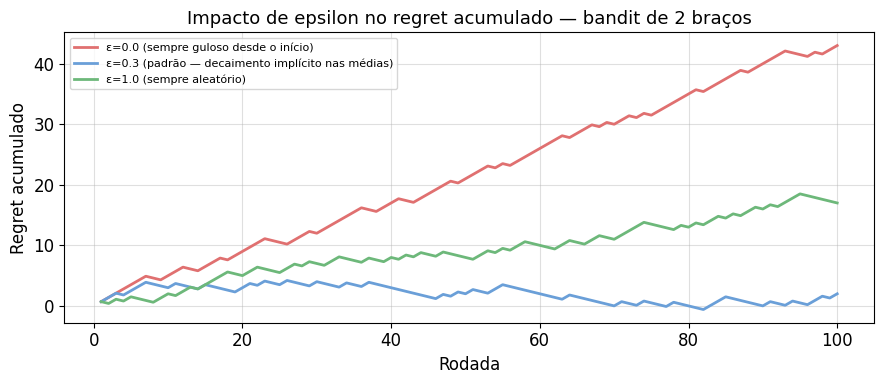


ε=0.0 → preso no braço 0 se ele foi escolhido primeiro (exploração insuficiente)
ε=1.0 → nunca aproveita o que aprendeu (exploração excessiva)
ε=0.3 → equilibra exploração e aproveitamento, minimizando o regret


In [3]:
import numpy as np
import matplotlib.pyplot as plt

P_VERDADEIRA_D3 = [0.3, 0.7]   # mesmo ambiente do D1
N_RODADAS_D3    = 100
EPSILONS_D3     = [0.0, 0.3, 1.0]
ROTULOS_D3      = ['ε=0.0 (sempre guloso desde o início)',
                   'ε=0.3 (padrão — decaimento implícito nas médias)',
                   'ε=1.0 (sempre aleatório)']
CORES_D3        = ['#e07070', '#6a9fd8', '#6db87a']

plt.figure(figsize=(9, 4))
for eps, rotulo, cor in zip(EPSILONS_D3, ROTULOS_D3, CORES_D3):
    rng_exp = np.random.default_rng(42)
    q = [0.0, 0.0]; n = [0, 0]; regret_acum = 0.0; curva = []
    for rodada in range(N_RODADAS_D3):
        acao = int(rng_exp.integers(2)) if rng_exp.random() < eps else int(np.argmax(q))
        r    = int(rng_exp.random() < P_VERDADEIRA_D3[acao])
        n[acao] += 1
        q[acao] += (r - q[acao]) / n[acao]
        regret_acum += P_VERDADEIRA_D3[1] - r
        curva.append(regret_acum)
    plt.plot(range(1, N_RODADAS_D3 + 1), curva, label=rotulo, color=cor, linewidth=2)
    print(f"{rotulo}: regret final = {curva[-1]:.2f}  |  Q estimado = {[round(x,3) for x in q]}")

plt.title('Impacto de epsilon no regret acumulado — bandit de 2 braços')
plt.xlabel('Rodada')
plt.ylabel('Regret acumulado')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
print()
print("ε=0.0 → preso no braço 0 se ele foi escolhido primeiro (exploração insuficiente)")
print("ε=1.0 → nunca aproveita o que aprendeu (exploração excessiva)")
print("ε=0.3 → equilibra exploração e aproveitamento, minimizando o regret")

O gráfico compara a evolução do regret acumulado para diferentes valores de ε. Ele permite observar visualmente que políticas aparentemente simples podem gerar trajetórias de aprendizado muito diferentes.

A curva associada a ε = 0.0 tende a representar o risco de uma política prematuramente gulosa: o agente toma decisões com base em pouca evidência e pode permanecer explorando mal o ambiente. A curva de ε = 1.0 representa o extremo oposto: o agente coleta informação, mas não transforma essa informação em uma estratégia melhor de decisão. Já a curva de ε = 0.3 mostra o benefício de manter exploração suficiente para descobrir boas ações e, ao mesmo tempo, aproveitar o conhecimento adquirido.

A leitura mais importante do gráfico não é apenas qual curva termina com menor regret, mas por que isso ocorre. O desempenho do agente depende tanto da qualidade das estimativas Q(a) quanto da política usada para transformar essas estimativas em ações.

## Considerações éticas e de fairness no RL de recomendação

O agente de RL aprende a maximizar *exatamente* a recompensa definida pelo desenvolvedor. No contexto MovieLens, isso levanta questões práticas importantes:

**Viés na função de recompensa:** a recompensa `gostou = nota ≥ 4` reflete preferências históricas — que podem estar enviesadas por sub-representação de filmes de determinados países, idiomas ou orçamentos. O agente otimiza o que você define, não o que você quer que ele faça.

**Exploração forçada:** durante a fase de exploração (ε-greedy), o agente recomenda itens aleatórios. Em sistemas reais com usuários reais, isso expõe usuários a recomendações potencialmente ruins. Em domínios de alto impacto (saúde, crédito), exploração aleatória pode ter consequências graves — o que motiva pesquisa em *safe exploration*.

**Amplificação de popularidade:** agentes treinados para maximizar cliques ou notas tendem a recomendar filmes populares — que têm maior probabilidade histórica de recompensa. Isso reduz a exposição de itens menos conhecidos e aprofunda o viés de popularidade ao longo do tempo (*popularity feedback loop*).

**Boas práticas para o Desafio Final:** definir a recompensa com cuidado, incluir métricas de diversidade e cobertura do catálogo na avaliação, e documentar explicitamente o que o agente otimiza e o que ele pode estar sacrificando implicitamente.

## Bloco 3 — Código didático mínimo

Neste bloco, a formulação de Aprendizado por Reforço é apresentada em sua forma mais simples: um problema de **bandit de recomendação**. A ideia central é representar cada filme candidato como uma ação possível e observar, após cada recomendação, se o usuário produziu uma resposta positiva ou não.

Diferentemente dos métodos supervisionados, o agente não recebe previamente um rótulo dizendo qual filme deveria recomendar em cada rodada. Ele precisa escolher uma ação, observar a recompensa e atualizar sua estimativa de valor para aquela ação. Nesse contexto, o valor aprendido não representa uma função Q(s,a) completa, pois o estado não varia explicitamente no exemplo mínimo. O que o agente estima é um vetor de valores **Q(a)**, em que cada posição indica o retorno médio observado para uma ação.

Esse exemplo é propositalmente simples. O objetivo não é construir um sistema de recomendação completo, mas tornar visível o mecanismo fundamental de RL: decidir, receber feedback e ajustar o comportamento com base na experiência.

Depois do exemplo artificial com dois braços, o notebook aplica a mesma lógica a um cenário de recomendação inspirado no MovieLens. Agora, cada ação corresponde a recomendar um filme candidato. A recompensa representa uma resposta positiva do usuário, definida a partir do histórico de avaliações.

A tabela de candidatos não deve ser lida como uma lista definitiva dos “melhores filmes” do dataset. Ela representa o conjunto de ações disponível para aquele experimento específico. Para cada candidato, o notebook estima uma probabilidade histórica de satisfação, que funciona como a probabilidade verdadeira usada pelo ambiente simulado.

Essa mudança aproxima o exemplo do problema de negócio: o agente precisa escolher qual filme recomendar agora, observar se a recomendação gerou uma resposta positiva e atualizar sua preferência entre os candidatos.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RATINGS_PATH = 'data/movielens/ratings.csv'
SEED = 42
rng  = np.random.default_rng(SEED)

try:
    ratings = pd.read_csv(RATINGS_PATH)
except FileNotFoundError:
    raise FileNotFoundError(
        'ratings.csv não encontrado. '
        'Execute o notebook 01_contexto_movielens.ipynb para preparar os dados.'
    )

# Recompensa: nota >= 4 → 1 (satisfação), caso contrário → 0
ratings['recompensa'] = (ratings['rating'] >= 4).astype(int)

# Selecionar o usuário com mais avaliações (contexto fixo para o episódio)
usuario_id = (
    ratings.groupby('userId')['rating'].count()
    .idxmax()
)
perfil = ratings[ratings['userId'] == usuario_id].agg(
    total_avaliacoes=('rating', 'count'),
    nota_media=('rating', 'mean'),
).round(2)

print(f'Usuário selecionado: userId={usuario_id}')
display(perfil.rename(columns=str).T)

# 3 filmes candidatos: filmes com >= 30 avaliações, escolhidos com semente fixa
candidatos = (
    ratings.groupby('movieId')
    .agg(p_recompensa=('recompensa', 'mean'), n=('recompensa', 'count'))
    .query('n >= 30')
    .sample(3, random_state=SEED)
    .sort_values('p_recompensa', ascending=False)
    .reset_index()
)
candidatos.index.name = 'ação'

print('\nFilmes candidatos (ações disponíveis):')
display(candidatos[['movieId', 'p_recompensa', 'n']].round(3))

Usuário selecionado: userId=414


,total_avaliacoes,nota_media
rating,2698.0,3.39



Filmes candidatos (ações disponíveis):


,movieId,p_recompensa,n
ação,,,
0,333,0.580,50
1,1663,0.500,34
2,163,0.455,66


In [5]:
N_ACOES   = len(candidatos)
TRUE_P    = candidatos['p_recompensa'].to_numpy()
EPSILON   = 0.3
N_RODADAS = 50

# Estimativas de Q(a) e contadores — sem bibliotecas de RL
q = np.zeros(N_ACOES)   # valor estimado de cada ação
n = np.zeros(N_ACOES)   # quantas vezes cada ação foi escolhida

log = []
recompensa_acumulada = 0

for rodada in range(1, N_RODADAS + 1):
    # Política epsilon-greedy
    if rng.random() < EPSILON:
        acao = int(rng.integers(N_ACOES))   # exploração
        tipo = 'exploração'
    else:
        acao = int(np.argmax(q))            # aproveitamento
        tipo = 'aproveitamento'

    # Ambiente: recompensa estocástica com base na probabilidade histórica do filme
    recompensa = int(rng.random() < TRUE_P[acao])
    recompensa_acumulada += recompensa

    # Atualização incremental de Q(a)
    n[acao] += 1
    q[acao] += (recompensa - q[acao]) / n[acao]

    log.append({
        'rodada':               rodada,
        'movieId':              candidatos.loc[acao, 'movieId'],
        'tipo':                 tipo,
        'recompensa':           recompensa,
        'recompensa_acumulada': recompensa_acumulada,
    })

df_log = pd.DataFrame(log)

print('Primeiras 10 interações do episódio:')
display(df_log.head(10))
print(f'\nRecompensa acumulada ao final de {N_RODADAS} rodadas: {recompensa_acumulada}')

Primeiras 10 interações do episódio:


,rodada,movieId,tipo,recompensa,recompensa_acumulada
0,1,333,aproveitamento,1,1
1,2,333,aproveitamento,0,1
2,3,1663,exploração,0,1
3,4,333,aproveitamento,1,2
4,5,333,aproveitamento,1,3
5,6,333,aproveitamento,0,3
6,7,333,aproveitamento,1,4
7,8,163,exploração,0,4
8,9,163,exploração,0,4
9,10,333,aproveitamento,1,5



Recompensa acumulada ao final de 50 rodadas: 31



A tabela com as primeiras interações mostra o processo de aprendizagem acontecendo passo a passo. Cada rodada registra qual filme foi recomendado, qual recompensa foi observada e como as estimativas do agente evoluíram.

No início do episódio, as estimativas Q(a) ainda são instáveis, porque cada filme foi observado poucas vezes. Uma única recompensa positiva ou negativa pode alterar bastante o valor estimado de uma ação. Com o aumento do número de interações, as estimativas tendem a se estabilizar, pois passam a refletir uma média de várias experiências.

Essa tabela é importante porque revela algo que gráficos agregados podem esconder: o aprendizado em RL não acontece de uma vez. Ele é incremental, ruidoso e dependente da sequência de ações escolhidas pelo agente.

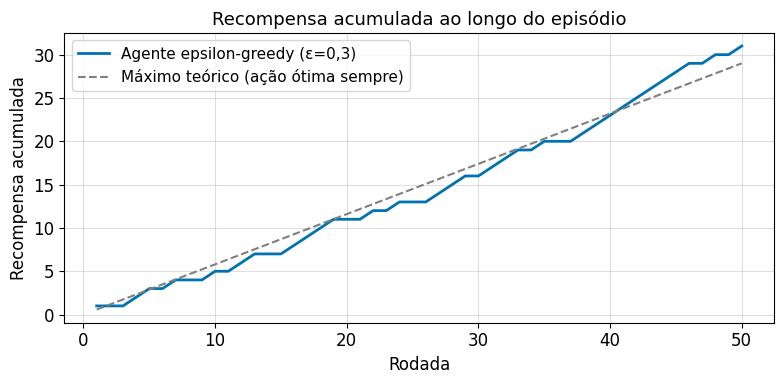


Estimativas finais de Q(a) vs. probabilidade histórica real:


,movieId,p_recompensa,q_estimado,n_escolhas
ação,,,,
0,333,0.580000,0.658,38
1,1663,0.500000,0.600,5
2,163,0.454545,0.429,7


In [6]:
# Requer execução das células anteriores (df_log, TRUE_P, q, n, candidatos)
# Recompensa acumulada: agente vs. máximo teórico (sempre escolher a melhor ação)
otimo_por_rodada = np.arange(1, N_RODADAS + 1) * TRUE_P.max()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_log['rodada'], df_log['recompensa_acumulada'],
        label='Agente epsilon-greedy (ε=0,3)', linewidth=2)
ax.plot(df_log['rodada'], otimo_por_rodada,
        linestyle='--', color='gray', label='Máximo teórico (ação ótima sempre)')
ax.set_xlabel('Rodada')
ax.set_ylabel('Recompensa acumulada')
ax.set_title('Recompensa acumulada ao longo do episódio')
ax.legend()
plt.tight_layout()
plt.show()

# Estimativas finais de Q vs. probabilidades reais
resultado = candidatos[['movieId', 'p_recompensa']].copy()
resultado['q_estimado'] = q.round(3)
resultado['n_escolhas'] = n.astype(int)
print('\nEstimativas finais de Q(a) vs. probabilidade histórica real:')
display(resultado)

O gráfico de recompensa acumulada mostra como o desempenho do agente evolui ao longo do episódio. Quando a curva cresce com maior consistência, isso indica que o agente está conseguindo obter recompensas positivas com frequência razoável.

É importante lembrar que, em um bandit estocástico, mesmo a melhor ação não gera recompensa positiva sempre. Por isso, oscilações são esperadas. O objetivo do agente não é eliminar completamente a aleatoriedade, mas aumentar a frequência com que escolhe ações de maior retorno esperado.

A curva deve ser interpretada em conjunto com as estimativas Q(a). Um agente pode ter uma sequência inicial ruim por acaso e, ainda assim, aprender corretamente ao longo do tempo. Da mesma forma, uma sequência inicial favorável pode gerar uma impressão exagerada sobre uma ação que ainda foi pouco testada.

## Bloco 4 — Interpretação pedagógica

### O que o gráfico mostra

A curva de recompensa acumulada reflete o comportamento da política epsilon-greedy ao longo de 50 rodadas. Algumas observações esperadas:

- **Tendência crescente:** à medida que o agente acumula experiência, a estimativa de Q converge para os valores reais de cada ação. Nos primeiros turnos, escolhas aleatórias (exploração) dominam; nas rodadas finais, o aproveitamento da melhor ação estimada é mais frequente.
- **Distância do máximo teórico:** a linha tracejada representa o retorno obtido se o agente sempre escolhesse a ação ótima. A diferença entre a curva real e o máximo teórico é o **arrependimento** (*regret*) acumulado — o custo da exploração.
- **Degraus:** cada recompensa 0 cria uma horizontal na curva; cada recompensa 1 cria uma subida. A frequência dessas subidas reflete a qualidade da política aprendida.

### O que muda com epsilon diferente

| Valor de ε | Comportamento | Consequência |
|---|---|---|
| ε alto (ex.: 0,8) | Explora muito, aproveita pouco | Curva cresce devagar; o agente descobre bem o espaço mas acumula menos recompensa |
| ε = 0,3 (padrão) | Equilíbrio entre explorar e aproveitar | Curva cresce de forma razoável e converge para perto do ótimo |
| ε baixo (ex.: 0,05) | Aproveita quase sempre | Converge rápido se a melhor ação já foi encontrada; fica preso se não foi |

### Conexão com política e exploração

Os turnos marcados como *exploração* na tabela correspondem a ε = 0,3 da política — a aleatoriedade intencional que mantém o agente exposto a alternativas. Os turnos de *aproveitamento* mostram a ação de maior Q estimado até aquele momento.

À medida que os valores de Q convergem para as probabilidades históricas reais (visíveis na tabela de resultado final), o aproveitamento passa a selecionar consistentemente a ação ótima. Esse é o mecanismo central do aprendizado por reforço: a política melhora porque as estimativas de valor melhoram com a experiência acumulada.

## Bloco 5 — Limites e transição

### O que este bandit não modela

A implementação deste notebook é uma simplificação deliberada. Ela captura a lógica central de ação-recompensa, mas deixa de lado elementos do MDP completo:

- **Sem estado que muda:** o estado do usuário é fixo durante todo o episódio. Em um sistema real, cada recomendação atualiza o histórico e o perfil do usuário — o estado seguinte depende da ação tomada. O bandit ignora essa dependência temporal.
- **Sem horizonte temporal real:** as 50 rodadas são independentes entre si. Não há consequências de longo prazo: recomendar filme A agora não afeta quais filmes estarão disponíveis ou o que o usuário vai querer nas próximas rodadas.
- **Sem planejamento:** o agente não raciocina sobre recompensas futuras — apenas atualiza estimativas de valor imediato. Algoritmos completos de RL (Q-Learning, DQN) propagam o valor de estados futuros de volta para estados anteriores, o que permite planejamento implícito.
- **Candidatos fixos:** a lista de 3 filmes é estática. Um sistema real opera sobre um catálogo de milhares de itens, com candidatos que mudam a cada interação.

### Por que o bandit ainda é útil

Apesar dessas limitações, o bandit contextual é amplamente usado em sistemas de recomendação reais quando:
- o estado do usuário é aproximadamente estacionário em curto prazo,
- a latência de decisão é crítica,
- o espaço de ações é grande mas pode ser reduzido a poucos candidatos.

### O que vem a seguir no curso

As próximas aulas aprofundam os algoritmos que tratam o problema completo do MDP:

| Algoritmo | O que resolve |
|---|---|
| Q-Learning | Aprende Q(s,a) em ambientes com estados discretos |
| DQN | Aproxima Q(s,a) com redes neurais para espaços de estado grandes |
| PPO | Otimiza diretamente a política em ambientes contínuos e complexos |

### O que vem a seguir nesta aula

O próximo notebook apresenta a comparação lado a lado dos três paradigmas vistos até aqui, consolidando as diferenças de sinal, dependência temporal e objetivo de cada um.

## Glossário — termos introduzidos neste notebook

| Termo (EN) | Tradução (PT) | Descrição |
|---|---|---|
| multi-armed bandit | bandit multi-braço | Problema de decisão sequencial sem estado variável: maximizar recompensa entre k ações. |
| MDP | MDP | Markov Decision Process — formalização de decisão sequencial com estados, ações e recompensa. |
| epsilon-greedy | ε-greedy | Política que explora com prob. ε e aproveita a melhor ação conhecida com prob. 1−ε. |
| regret | arrependimento | Diferença entre o retorno do agente e o retorno do agente ótimo; custo da exploração. |
| Q-value | valor Q | Q(a) — estimativa do retorno esperado ao escolher a ação a. |

> Glossário completo do curso: [docs/glossario.md](../../docs/glossario.md)

## Leituras e referências

- Sutton, R. S.; Barto, A. G. *Reinforcement Learning: An Introduction*. 2. ed. MIT Press, 2018. Cap. 2 (Multi-armed Bandits) e Cap. 3 (MDPs). Disponível em: http://incompleteideas.net/book/the-book-2nd.html (acesso em 2026-03-07).
- Puterman, M. L. *Markov Decision Processes: Discrete Stochastic Dynamic Programming*. Wiley, 1994. (Referência clássica para a formulação formal do MDP.)
- Li, L. et al. A Contextual-Bandit Approach to Personalized News Article Recommendation. *WWW*, 2010. (Aplicação de bandit contextual em recomendação.)
- MovieLens (GroupLens): https://grouplens.org/datasets/movielens/ (acesso em 2026-03-07).
- Roteiro da Aula 01, Vídeo 4: `roteiros/Aula 01 - Roteiro video aula.md`.